<a href="https://colab.research.google.com/github/akhilanama06/FSD/blob/main/fake_job_internship_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Upload your CSV dataset (e.g. fake_job_postings.csv)


Saving fake_job_postings.csv to fake_job_postings.csv

================ 1. DATASET ANALYSIS ================
Shape : (17880, 18)

Columns & types:
 job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object

First rows:
    job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)    

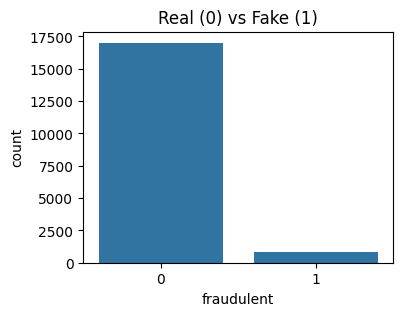


================ 2. DATA PREPROCESSING ================
Feature matrix: (14304, 5208) | train: 14304 | test: 3576

================ 3. FEATURE SELECTION (Chi-Square, top-k) ================
Selected 1500 of 5208 features


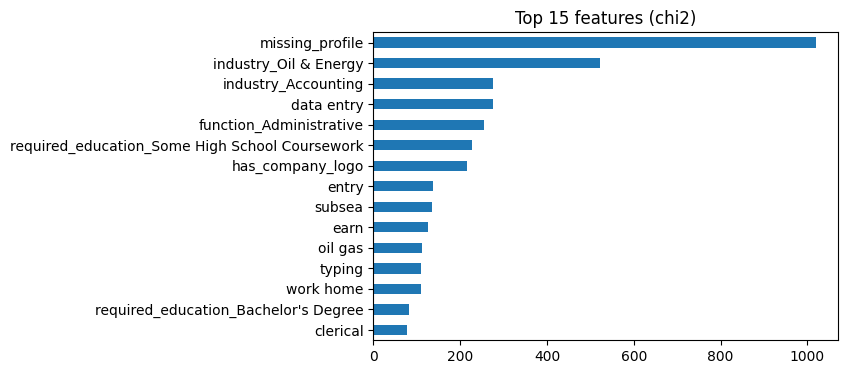


================ 4. DATA MINING MODELS ================

================ 5. EVALUATION METRICS COMPARISON ================
   Setting               Model  Accuracy  Precision  Recall     F1  ROC-AUC
Without FS       Decision Tree    0.9474     0.4762  0.8671 0.6148   0.9146
Without FS         Naive Bayes    0.9662     0.6912  0.5434 0.6084   0.9307
Without FS Logistic Regression    0.9664     0.6015  0.9075 0.7235   0.9866
Without FS                 SVM    0.9863     0.9247  0.7803 0.8464   0.9860
Without FS       Random Forest    0.9790     0.9804  0.5780 0.7273   0.9916
   With FS       Decision Tree    0.9455     0.4652  0.8497 0.6012   0.9054
   With FS         Naive Bayes    0.9695     0.7286  0.5896 0.6518   0.9384
   With FS Logistic Regression    0.9469     0.4745  0.9133 0.6245   0.9821
   With FS                 SVM    0.9810     0.8723  0.7110 0.7834   0.9823
   With FS       Random Forest    0.9801     1.0000  0.5896 0.7418   0.9918


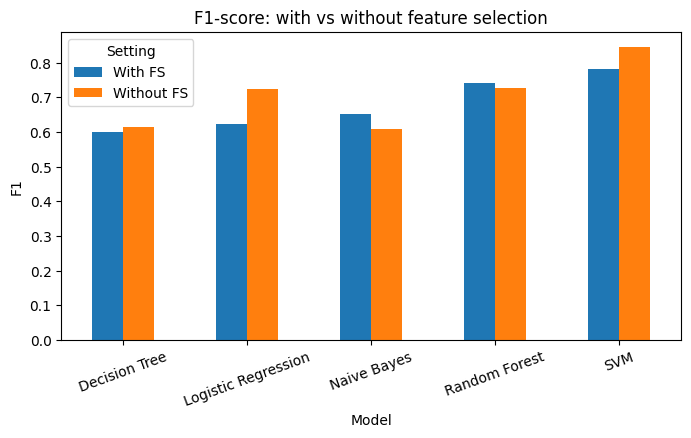


BEST MODEL -> SVM (Without FS) | F1=0.8464 | AUC=0.986
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      3403
        Fake       0.92      0.78      0.85       173

    accuracy                           0.99      3576
   macro avg       0.96      0.89      0.92      3576
weighted avg       0.99      0.99      0.99      3576



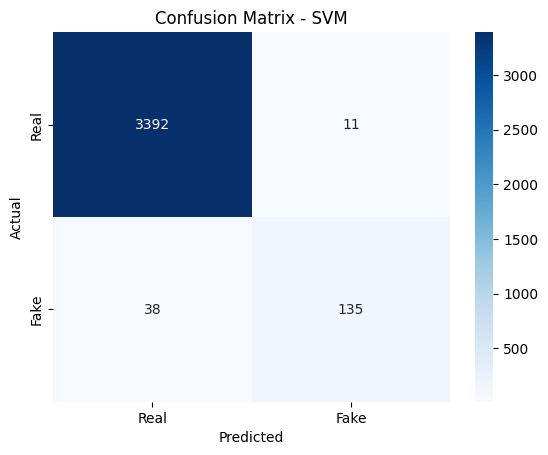


================ EXPLAINABLE AI ================


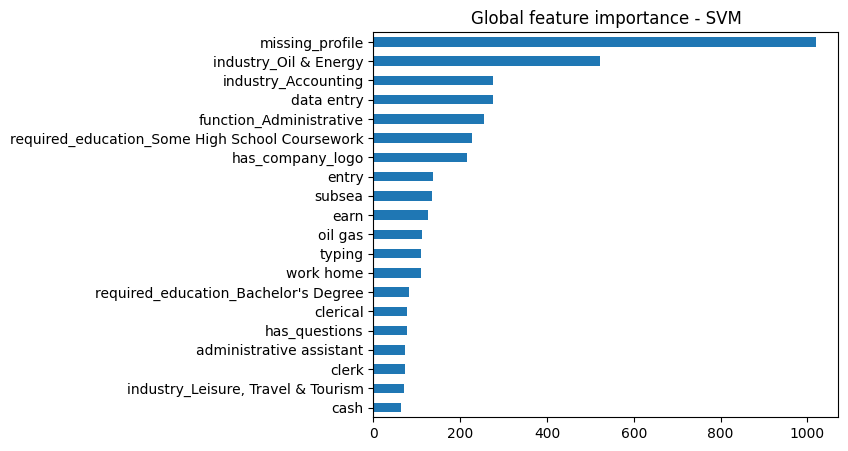

LIME explanation (word -> weight toward Fake):
  earn                 +0.247
  URGENT               +0.124
  Work                 +0.123
  needed               +0.118
  hiring               +0.082
  home                 +0.067
  contact              -0.057
  immediately          -0.043


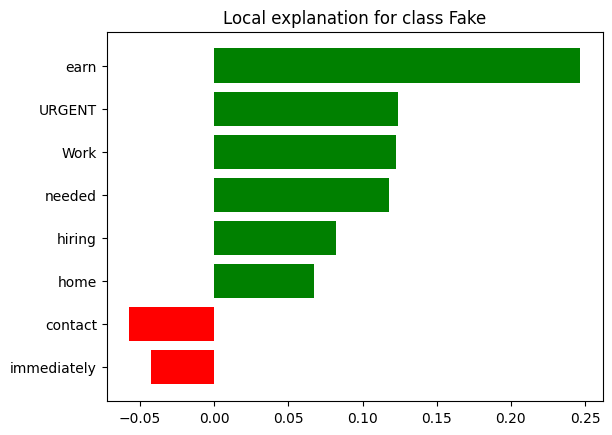


================ 6. DEPLOYMENT (Web App) ================
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://60a1400e9b6bd0f371.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



================ SUSTAINABLE DEVELOPMENT GOALS ================
Primary   : SDG 8  - Decent Work and Economic Growth
            (protects job seekers/students from employment scams, promotes safe, decent work)
Secondary : SDG 4  - Quality Education (safe internships & career pathways for students)
            SDG 16 - Peace, Justice and Strong Institutions (reduces online fraud, builds trust)
            SDG 9  - Industry, Innovation and Infrastructure (AI-based trust infrastructure)



In [4]:
# =====================================================================
#  FAKE JOB / INTERNSHIP DETECTION USING DATA MINING + MACHINE LEARNING
#  Single-program Google Colab notebook (paste into ONE cell, or split
#  at the "# ---- CELL" markers).
#  Dataset: any CSV with a text/feature columns + a fraud label column.
#  Recommended: Kaggle "Real / Fake Job Posting Prediction"
#  (fake_job_postings.csv, label column = 'fraudulent')
# =====================================================================

# ---- CELL 1 : install + imports ------------------------------------
!pip -q install gradio shap lime

import re, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from google.colab import files
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.preprocessing import MinMaxScaler

# ---- CELL 2 : upload dataset ---------------------------------------
print("Upload your CSV dataset (e.g. fake_job_postings.csv)")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_csv(fname)

# ---- 1. DATASET ANALYSIS -------------------------------------------
print("\n================ 1. DATASET ANALYSIS ================")
print("Shape :", df.shape)
print("\nColumns & types:\n", df.dtypes)
print("\nFirst rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

# >>> CHANGE THIS if your label column has a different name <<<
LABEL = "fraudulent"
if LABEL not in df.columns:
    # try to auto-detect a label column
    for c in df.columns:
        if c.lower() in ("fraudulent", "fraud", "label", "target", "class", "is_fake"):
            LABEL = c
            break
print("Label column used:", LABEL)

print("\nClass distribution:\n", df[LABEL].value_counts())
plt.figure(figsize=(4, 3))
sns.countplot(x=df[LABEL]); plt.title("Real (0) vs Fake (1)"); plt.show()

# ---- 2. DATA PREPROCESSING -----------------------------------------
print("\n================ 2. DATA PREPROCESSING ================")
df = df.drop_duplicates().reset_index(drop=True)

# Text columns (use whichever exist in your dataset)
text_cols = [c for c in ["title", "company_profile", "description",
                         "requirements", "benefits"] if c in df.columns]
if not text_cols:  # fallback: use all object columns as text
    text_cols = [c for c in df.select_dtypes("object").columns if c != LABEL]

# Categorical / numeric columns
cat_cols = [c for c in ["employment_type", "required_experience",
                        "required_education", "industry", "function"]
            if c in df.columns]
bin_cols = [c for c in ["telecommuting", "has_company_logo", "has_questions"]
            if c in df.columns]

df[text_cols] = df[text_cols].fillna("")
df[cat_cols] = df[cat_cols].fillna("unknown")
for c in bin_cols:
    df[c] = df[c].fillna(0).astype(int)

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+", " url ", t)
    t = re.sub(r"\S+@\S+", " email ", t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["text"] = df[text_cols].agg(" ".join, axis=1).apply(clean_text)

# Hand-crafted "scam signal" features (data mining of patterns)
scam_words = ["urgent", "immediately", "fee", "registration fee", "deposit",
              "whatsapp", "telegram", "gmail", "yahoo", "earn", "per day",
              "work from home", "no experience", "limited seats", "wire transfer"]
df["text_len"]     = df["text"].str.len()
df["word_count"]   = df["text"].str.split().str.len()
df["scam_hits"]    = df["text"].apply(lambda t: sum(w in t for w in scam_words))
df["has_url"]      = df["text"].str.contains(r"\burl\b").astype(int)
df["has_email"]    = df["text"].str.contains(r"\bemail\b").astype(int)
df["exclaims"]     = df[text_cols].agg(" ".join, axis=1).str.count("!")
df["missing_profile"] = (df["company_profile"].str.len() == 0).astype(int) \
                         if "company_profile" in df.columns else 0

num_cols = ["text_len", "word_count", "scam_hits", "has_url", "has_email",
            "exclaims", "missing_profile"] + bin_cols

# Encode categoricals as dummies
cat_dummies = pd.get_dummies(df[cat_cols], drop_first=False) if cat_cols else pd.DataFrame(index=df.index)

y = df[LABEL].astype(int).values
X_train_idx, X_test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, stratify=y, random_state=42)

# TF-IDF on text (fit on train only to avoid leakage)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                        stop_words="english", min_df=3)
T_train = tfidf.fit_transform(df.loc[X_train_idx, "text"])
T_test  = tfidf.transform(df.loc[X_test_idx, "text"])

# Scale numeric features to [0,1] (needed for Naive Bayes / chi2 as well)
scaler = MinMaxScaler()
N_train = scaler.fit_transform(df.loc[X_train_idx, num_cols])
N_test  = scaler.transform(df.loc[X_test_idx, num_cols])

C_train = cat_dummies.iloc[X_train_idx].values.astype(float)
C_test  = cat_dummies.iloc[X_test_idx].values.astype(float)

X_train_full = hstack([T_train, csr_matrix(N_train), csr_matrix(C_train)]).tocsr()
X_test_full  = hstack([T_test,  csr_matrix(N_test),  csr_matrix(C_test)]).tocsr()
feature_names = np.array(list(tfidf.get_feature_names_out()) + num_cols +
                         list(cat_dummies.columns))
y_train, y_test = y[X_train_idx], y[X_test_idx]
print("Feature matrix:", X_train_full.shape, "| train:", len(y_train), "| test:", len(y_test))

# ---- 3. FEATURE SELECTION ------------------------------------------
print("\n================ 3. FEATURE SELECTION (Chi-Square, top-k) ================")
K = min(1500, X_train_full.shape[1])
selector = SelectKBest(chi2, k=K).fit(X_train_full, y_train)
X_train_fs = selector.transform(X_train_full)
X_test_fs  = selector.transform(X_test_full)
sel_names  = feature_names[selector.get_support()]
print(f"Selected {K} of {X_train_full.shape[1]} features")
top = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False).head(15)
top.plot(kind="barh", figsize=(6, 4), title="Top 15 features (chi2)"); plt.gca().invert_yaxis(); plt.show()

# ---- 4. MODELS (supervised) ----------------------------------------
print("\n================ 4. DATA MINING MODELS ================")
def get_models():
    return {
        "Decision Tree":       DecisionTreeClassifier(max_depth=20, class_weight="balanced", random_state=42),
        "Naive Bayes":         MultinomialNB(),
        "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "SVM":                 CalibratedClassifierCV(LinearSVC(class_weight="balanced"), cv=3),
        "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                      n_jobs=-1, random_state=42),
    }

def evaluate(Xtr, Xte, tag):
    rows, fitted = [], {}
    for name, m in get_models().items():
        m.fit(Xtr, y_train)
        p = m.predict(Xte)
        prob = m.predict_proba(Xte)[:, 1]
        rows.append({"Setting": tag, "Model": name,
                     "Accuracy":  accuracy_score(y_test, p),
                     "Precision": precision_score(y_test, p, zero_division=0),
                     "Recall":    recall_score(y_test, p),
                     "F1":        f1_score(y_test, p),
                     "ROC-AUC":   roc_auc_score(y_test, prob)})
        fitted[name] = m
    return pd.DataFrame(rows), fitted

res_all, models_all = evaluate(X_train_full, X_test_full, "Without FS")
res_fs,  models_fs  = evaluate(X_train_fs,   X_test_fs,   "With FS")

# ---- 5. COMPARE EVALUATION METRICS ---------------------------------
print("\n================ 5. EVALUATION METRICS COMPARISON ================")
results = pd.concat([res_all, res_fs]).round(4)
print(results.to_string(index=False))

pivot = results.pivot(index="Model", columns="Setting", values="F1")
pivot.plot(kind="bar", figsize=(8, 4), title="F1-score: with vs without feature selection")
plt.ylabel("F1"); plt.xticks(rotation=20); plt.show()

# pick best model by F1 (fake class matters more than raw accuracy)
best_row = results.sort_values(["F1", "ROC-AUC"], ascending=False).iloc[0]
best_name, best_setting = best_row["Model"], best_row["Setting"]
print(f"\nBEST MODEL -> {best_name} ({best_setting}) | F1={best_row['F1']} | AUC={best_row['ROC-AUC']}")

use_fs = best_setting == "With FS"
best_model = (models_fs if use_fs else models_all)[best_name]
Xte_best = X_test_fs if use_fs else X_test_full
pred = best_model.predict(Xte_best)
print(classification_report(y_test, pred, target_names=["Real", "Fake"]))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.title(f"Confusion Matrix - {best_name}"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

# ---- EXPLAINABLE AI -------------------------------------------------
print("\n================ EXPLAINABLE AI ================")
# (a) Global explanation: top words/features that push towards FAKE vs REAL
names_used = sel_names if use_fs else feature_names
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=names_used)
elif hasattr(best_model, "coef_"):
    imp = pd.Series(best_model.coef_[0], index=names_used)
else:  # calibrated SVM / others -> use chi2 scores
    imp = pd.Series(selector.scores_, index=feature_names)
imp.abs().sort_values(ascending=False).head(20).plot(
    kind="barh", figsize=(6, 5), title=f"Global feature importance - {best_name}")
plt.gca().invert_yaxis(); plt.show()

# (b) Local explanation with LIME (explains ONE prediction in words)
from lime.lime_text import LimeTextExplainer

def full_vector(text, num_vals, cat_vals=None):
    t = tfidf.transform([clean_text(text)])
    n = scaler.transform(pd.DataFrame([num_vals], columns=num_cols))
    c = np.zeros((1, C_train.shape[1])) if cat_vals is None else cat_vals
    X = hstack([t, csr_matrix(n), csr_matrix(c)]).tocsr()
    return selector.transform(X) if use_fs else X

def numeric_from_text(text):
    t = clean_text(text)
    d = {"text_len": len(t), "word_count": len(t.split()),
         "scam_hits": sum(w in t for w in scam_words),
         "has_url": int(" url " in f" {t} "), "has_email": int(" email " in f" {t} "),
         "exclaims": text.count("!"), "missing_profile": 0}
    for b in bin_cols: d[b] = 0
    return [d[c] for c in num_cols]

def proba_text(texts):
    out = []
    for tx in texts:
        out.append(best_model.predict_proba(full_vector(tx, numeric_from_text(tx)))[0])
    return np.array(out)

lime_exp = LimeTextExplainer(class_names=["Real", "Fake"])
sample_fake = ("URGENT hiring! Work from home, earn 5000 per day. No experience needed. "
               "Pay registration fee and contact us on WhatsApp or Gmail immediately.")
exp = lime_exp.explain_instance(sample_fake, proba_text, num_features=8, num_samples=300)
print("LIME explanation (word -> weight toward Fake):")
for w, wt in exp.as_list(): print(f"  {w:20s} {wt:+.3f}")
exp.as_pyplot_figure(); plt.show()

# ---- 6. SAVE + DEPLOY WEB APP (Gradio) -----------------------------
print("\n================ 6. DEPLOYMENT (Web App) ================")
joblib.dump({"model": best_model, "tfidf": tfidf, "scaler": scaler,
             "selector": selector, "use_fs": use_fs, "num_cols": num_cols,
             "cat_cols": list(cat_dummies.columns)}, "fake_job_model.pkl")

import gradio as gr

EMP_TYPES = ["unknown"] + sorted({c.split("_", 2)[-1] for c in cat_dummies.columns
                                  if c.startswith("employment_type")})

def predict_job(title, company_profile, description, requirements, benefits,
                employment_type, has_logo, has_questions, telecommuting):
    raw = " ".join([title, company_profile, description, requirements, benefits])
    t = clean_text(raw)
    num = {"text_len": len(t), "word_count": len(t.split()),
           "scam_hits": sum(w in t for w in scam_words),
           "has_url": int(" url " in f" {t} "), "has_email": int(" email " in f" {t} "),
           "exclaims": raw.count("!"),
           "missing_profile": int(len(company_profile.strip()) == 0),
           "telecommuting": int(telecommuting), "has_company_logo": int(has_logo),
           "has_questions": int(has_questions)}
    nvals = [num.get(c, 0) for c in num_cols]

    cat_vec = np.zeros((1, C_train.shape[1]))
    col = f"employment_type_{employment_type}"
    if col in cat_dummies.columns:
        cat_vec[0, list(cat_dummies.columns).index(col)] = 1

    X = full_vector(raw, nvals, cat_vec)
    prob_fake = float(best_model.predict_proba(X)[0, 1])
    label = "FAKE / SUSPICIOUS" if prob_fake >= 0.5 else "LIKELY GENUINE"

    # Explainable AI: red-flag words found + LIME top words
    flags = [w for w in scam_words if w in t]
    try:
        e = lime_exp.explain_instance(raw, proba_text, num_features=6, num_samples=200)
        why = "\n".join(f"- '{w}' -> {'pushes to FAKE' if wt > 0 else 'pushes to REAL'} ({wt:+.2f})"
                        for w, wt in e.as_list())
    except Exception:
        why = "n/a"
    explanation = (f"Red-flag phrases found: {', '.join(flags) if flags else 'none'}\n\n"
                   f"Top words influencing the model (LIME):\n{why}")
    return label, {"Fake": prob_fake, "Genuine": 1 - prob_fake}, explanation

demo = gr.Interface(
    fn=predict_job,
    inputs=[gr.Textbox(label="Job / Internship Title"),
            gr.Textbox(label="Company Profile", lines=3),
            gr.Textbox(label="Job Description", lines=5),
            gr.Textbox(label="Requirements", lines=3),
            gr.Textbox(label="Benefits", lines=2),
            gr.Dropdown(EMP_TYPES, value="unknown", label="Employment Type"),
            gr.Checkbox(label="Company logo present?"),
            gr.Checkbox(label="Screening questions asked?"),
            gr.Checkbox(label="Remote / Work from home?")],
    outputs=[gr.Textbox(label="Prediction"),
             gr.Label(label="Probability"),
             gr.Textbox(label="Explainable AI - why?", lines=10)],
    title="Fake Job / Internship Detector",
    description=f"Model: {best_name} | Aligned with SDG 8 (Decent Work), SDG 4, SDG 16",
    examples=[["Data Entry Intern", "", "URGENT! Earn 5000 per day from home. No experience. "
               "Pay registration fee and contact on WhatsApp immediately.", "", "", "unknown", False, False, True]])

demo.launch(share=True, debug=False)   # opens a public link in Colab

# ---- 7. SDG MAPPING --------------------------------------------------
print("""
================ SUSTAINABLE DEVELOPMENT GOALS ================
Primary   : SDG 8  - Decent Work and Economic Growth
            (protects job seekers/students from employment scams, promotes safe, decent work)
Secondary : SDG 4  - Quality Education (safe internships & career pathways for students)
            SDG 16 - Peace, Justice and Strong Institutions (reduces online fraud, builds trust)
            SDG 9  - Industry, Innovation and Infrastructure (AI-based trust infrastructure)
""")